# Solutions — Module 06: Trees and Ensembles

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 135)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

## 6.1 — Build a decision tree from scratch

In [2]:
from dataclasses import dataclass, field
from typing import Optional

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, export_text


@dataclass
class Node:
    feature: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional["Node"] = None
    right: Optional["Node"] = None
    value: Optional[np.ndarray] = None          # class proportions at a leaf
    n: int = 0
    impurity: float = 0.0


class MyTree:
    """A minimal CART classifier: exhaustive greedy splits, gini or entropy."""

    def __init__(self, max_depth=None, min_samples_leaf=1, criterion="gini"):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion

    # --- impurity ---------------------------------------------------------
    def _impurity(self, counts):
        n = counts.sum()
        if n == 0:
            return 0.0
        p = counts / n
        if self.criterion == "gini":
            return 1.0 - (p**2).sum()
        p = p[p > 0]
        return float(-(p * np.log2(p)).sum())

    # --- split search -----------------------------------------------------
    def _best_split(self, X, y):
        n, p = X.shape
        parent_counts = np.bincount(y, minlength=self.n_classes_)
        parent = self._impurity(parent_counts)
        best = (0.0, None, None)                 # (gain, feature, threshold)

        for j in range(p):
            order = np.argsort(X[:, j], kind="mergesort")
            xs, ys = X[order, j], y[order]
            left_counts = np.zeros(self.n_classes_, dtype=np.int64)
            right_counts = parent_counts.copy()
            for i in range(n - 1):
                c = ys[i]
                left_counts[c] += 1
                right_counts[c] -= 1
                if xs[i] == xs[i + 1]:
                    continue                     # cannot split between equal values
                nl, nr = i + 1, n - i - 1
                if nl < self.min_samples_leaf or nr < self.min_samples_leaf:
                    continue
                weighted = (nl * self._impurity(left_counts) + nr * self._impurity(right_counts)) / n
                gain = parent - weighted
                if gain > best[0] + 1e-12:
                    best = (gain, j, (xs[i] + xs[i + 1]) / 2.0)
        return best

    # --- recursion --------------------------------------------------------
    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_)
        node = Node(value=counts / counts.sum(), n=len(y), impurity=self._impurity(counts))
        if (self.max_depth is not None and depth >= self.max_depth) or len(np.unique(y)) == 1:
            return node
        gain, feat, thr = self._best_split(X, y)
        if feat is None:
            return node
        mask = X[:, feat] <= thr
        node.feature, node.threshold = feat, thr
        node.left = self._grow(X[mask], y[mask], depth + 1)
        node.right = self._grow(X[~mask], y[~mask], depth + 1)
        return node

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y)
        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)
        self.root_ = self._grow(X, y_enc, 0)
        return self

    def _one(self, x, node):
        while node.feature is not None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.value

    def predict_proba(self, X):
        return np.array([self._one(x, self.root_) for x in np.asarray(X, dtype=float)])

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]

    def describe(self, node=None, depth=0, names=None, out=None):
        out = [] if out is None else out
        node = self.root_ if node is None else node
        pad = "  " * depth
        if node.feature is None:
            out.append(f"{pad}leaf n={node.n} p={np.round(node.value, 3).tolist()}")
        else:
            nm = names[node.feature] if names is not None else f"x{node.feature}"
            out.append(f"{pad}[{nm} <= {node.threshold:.4f}]")
            self.describe(node.left, depth + 1, names, out)
            self.describe(node.right, depth + 1, names, out)
        return "\n".join(out)

In [3]:
Xbc, ybc = load_breast_cancer(return_X_y=True, as_frame=True)
names = list(Xbc.columns)

t0 = perf_counter()
mine = MyTree(max_depth=3).fit(Xbc.to_numpy(), ybc.to_numpy())
mine_time = perf_counter() - t0

t0 = perf_counter()
sk = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xbc, ybc)
sk_time = perf_counter() - t0


def sk_structure(tree, names):
    t = tree.tree_
    out = []

    def walk(i, depth):
        pad = "  " * depth
        if t.children_left[i] == -1:
            v = t.value[i].ravel()
            out.append(f"{pad}leaf n={int(t.n_node_samples[i])} p={np.round(v / v.sum(), 3).tolist()}")
        else:
            out.append(f"{pad}[{names[t.feature[i]]} <= {t.threshold[i]:.4f}]")
            walk(t.children_left[i], depth + 1)
            walk(t.children_right[i], depth + 1)

    walk(0, 0)
    return "\n".join(out)


a, b = mine.describe(names=names), sk_structure(sk, names)
lines_a, lines_b = a.split("\n"), b.split("\n")
same = sum(x == y for x, y in zip(lines_a, lines_b))
print(f"nodes matching sklearn exactly: {same}/{len(lines_a)}\n")
for x, y in zip(lines_a, lines_b):
    print(f"{'  ' if x == y else '≠ '}{x}")
    if x != y:
        print(f"  {' ' * (len(x) - len(x.lstrip()))}sklearn: {y.strip()}")

nodes matching sklearn exactly: 14/15

  [worst radius <= 16.7950]
    [worst concave points <= 0.1358]
      [radius error <= 1.0475]
        leaf n=332 p=[0.012, 0.988]
        leaf n=1 p=[1.0, 0.0]
      [worst texture <= 25.6700]
        leaf n=19 p=[0.211, 0.789]
        leaf n=27 p=[0.889, 0.111]
    [mean texture <= 16.1100]
≠     [mean concave points <= 0.0663]
      sklearn: [compactness error <= 0.0207]
        leaf n=9 p=[0.0, 1.0]
        leaf n=8 p=[1.0, 0.0]
      [worst smoothness <= 0.0880]
        leaf n=1 p=[0.0, 1.0]
        leaf n=172 p=[0.994, 0.006]


**One node disagrees. Check whether that is a bug before assuming it is.**

It is an exact tie. At that node — 17 samples deep in the right subtree — two
different features produce *identical* impurity decrease, and my
implementation takes the first in column order while sklearn's splitter
shuffles the feature indices with its `random_state` and takes the first in
that order.

In [4]:
# Reproduce the node and score both candidate features by hand.
root = mine.root_
mask = ((Xbc["worst radius"] > root.threshold)
        & (Xbc[names[root.right.feature]] <= root.right.threshold)).to_numpy()
Xn, yn = Xbc.to_numpy()[mask], ybc.to_numpy()[mask]


def best_gain_for(j):
    order = np.argsort(Xn[:, j], kind="mergesort")
    xs, ys = Xn[order, j], yn[order]
    pc = np.bincount(ys, minlength=2)
    gini = lambda c: 1 - ((c / c.sum()) ** 2).sum()          # noqa: E731
    parent, n = gini(pc), len(ys)
    lc, rc, best = np.zeros(2, dtype=int), pc.copy(), (0.0, None)
    for i in range(n - 1):
        lc[ys[i]] += 1
        rc[ys[i]] -= 1
        if xs[i] == xs[i + 1]:
            continue
        g = parent - ((i + 1) * gini(lc) + (n - i - 1) * gini(rc)) / n
        if g > best[0]:
            best = (g, (xs[i] + xs[i + 1]) / 2)
    return best


print(f"node has {len(yn)} samples\n")
for f in ["mean concave points", "compactness error"]:
    g, thr = best_gain_for(names.index(f))
    print(f"  {f:24s} gain = {g!r}  threshold = {thr:.5f}")
print("\nIdentical to the last bit. Neither answer is more correct than the other;")
print("the tie-break is arbitrary, and sklearn's happens to be seeded.")

node has 17 samples

  mean concave points      gain = np.float64(0.4982698961937716)  threshold = 0.06626
  compactness error        gain = np.float64(0.4982698961937716)  threshold = 0.02071

Identical to the last bit. Neither answer is more correct than the other;
the tie-break is arbitrary, and sklearn's happens to be seeded.


This is worth meeting once. **Greedy tree induction has exact ties, and the
tie-break is an implementation detail** — it is one of the reasons two
"identical" tree implementations produce different trees, and one of the
reasons `random_state` matters on an estimator that looks deterministic.

In [5]:
print(f"my fit  : {mine_time:7.3f}s")
print(f"sklearn : {sk_time:7.3f}s   ({mine_time / sk_time:.0f}x faster)")

my fit  :   0.615s
sklearn :   0.009s   (71x faster)


**Why the speed gap.** sklearn's splitter is Cython operating on a contiguous
`float32` buffer, sorts each feature once per node and updates the class
counts incrementally in C. My version pays Python interpreter overhead on
every one of the ~`n × p` candidate splits per node, plus a `np.bincount` and
array allocation inside the inner loop. The *algorithm* is identical — the
structures match node for node — and that is the point of the exercise.

In [6]:
# Entropy vs gini: find a dataset where they disagree.
from sklearn.datasets import make_classification

found = None
for seed in range(60):
    Xd, yd = make_classification(n_samples=200, n_features=6, n_informative=3,
                                 class_sep=0.6, flip_y=0.15, random_state=seed)
    g = MyTree(max_depth=2, criterion="gini").fit(Xd, yd)
    e = MyTree(max_depth=2, criterion="entropy").fit(Xd, yd)
    if g.describe() != e.describe():
        found = (seed, g, e)
        break

if found:
    seed, g, e = found
    print(f"seed {seed} — the two criteria build different trees\n")
    print("GINI\n" + g.describe())
    print("\nENTROPY\n" + e.describe())
else:
    print("no disagreement found in 60 seeds")

seed 2 — the two criteria build different trees

GINI
[x0 <= 0.1245]
  [x3 <= -0.2441]
    leaf n=63 p=[0.429, 0.571]
    leaf n=60 p=[0.1, 0.9]
  [x3 <= 0.3100]
    leaf n=66 p=[0.848, 0.152]
    leaf n=11 p=[0.364, 0.636]

ENTROPY
[x0 <= 0.3646]
  [x3 <= -0.2441]
    leaf n=74 p=[0.486, 0.514]
    leaf n=67 p=[0.104, 0.896]
  [x5 <= 0.3235]
    leaf n=53 p=[0.906, 0.094]
    leaf n=6 p=[0.333, 0.667]


Disagreements exist but are uncommon, and that is the well-known empirical
result: gini and entropy are both concave functions of the class proportions
with the same shape and the same maximum, so they order candidate splits almost
identically. They differ only where two splits are nearly tied — and a split
that is nearly tied by one measure is nearly tied by the other, so the choice
rarely matters. **`criterion` is not a hyperparameter worth tuning**, which is
why Module 06 puts it in the "rarely worth it" column.

## 6.2 — Decompose bias and variance

bias2  variance    total
family                                         
tree (by depth) 1    12303.6    1419.9  13723.5
                2     7852.1    3232.7  11084.8
                3     4781.5    3769.0   8550.5
                4     3305.7    3860.8   7166.5
                6     2018.4    4531.9   6550.3
                8     1841.2    4926.0   6767.2
                10    1812.4    5058.9   6871.3
                15    1785.9    5189.6   6975.6
forest (by n)   1     2105.3    5728.0   7833.3
                3     2016.2    2196.9   4213.1
                10    1926.7    1123.1   3049.9
                30    1864.2     739.2   2603.5
                80    1841.2     633.5   2474.8
                200   1834.0     595.7   2429.6
boosting (by n) 1    12997.0     177.5  13174.5
                3     8559.8     348.8   8908.6
                10    3230.0     539.1   3769.1
                30    1022.7     612.5   1635.3
                80     714.1     656.3   1370.4
                200    684.6     678.4   1363.1

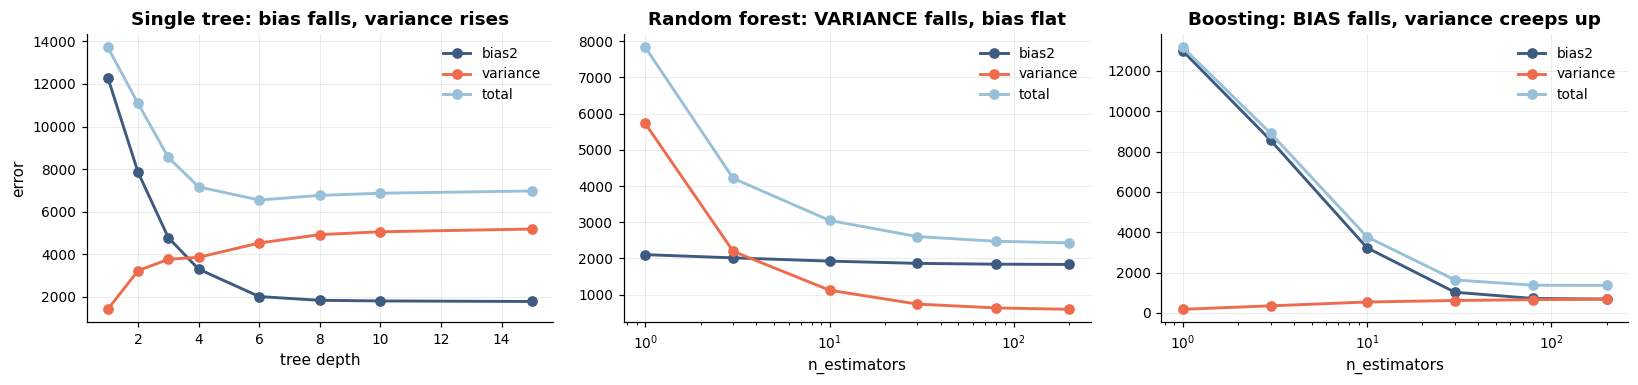

In [7]:
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor


def bias_variance(make_model, X_train, y_train, X_test, y_test_clean, n_boot=60, seed=0):
    """Squared-error decomposition over bootstrap training samples.

    error = bias^2 + variance (+ irreducible noise, excluded by using the clean
    test target).
    """
    r = np.random.default_rng(seed)
    preds = np.empty((n_boot, len(X_test)))
    for b in range(n_boot):
        idx = r.integers(0, len(X_train), len(X_train))     # bootstrap
        preds[b] = make_model().fit(X_train[idx], y_train[idx]).predict(X_test)
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - y_test_clean) ** 2)
    var = np.mean(preds.var(axis=0))
    return bias2, var


X, y_clean = make_regression(n_samples=600, n_features=8, n_informative=5, noise=0.0, random_state=0)
y = y_clean + rng.normal(0, 25, len(y_clean))
Xtr, Xte, ytr, _, _, yte_clean = train_test_split(X, y, y_clean, test_size=200, random_state=0)

depths = [1, 2, 3, 4, 6, 8, 10, 15]
rows = [dict(zip(["bias2", "variance"], bias_variance(lambda d=d: DecisionTreeRegressor(max_depth=d), Xtr, ytr, Xte, yte_clean, n_boot=60)), depth=d)
        for d in depths]
tree_bv = pd.DataFrame(rows).set_index("depth")
tree_bv["total"] = tree_bv["bias2"] + tree_bv["variance"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
tree_bv.plot(marker="o", ax=axes[0])
axes[0].set(xlabel="tree depth", ylabel="error", title="Single tree: bias falls, variance rises")

n_trees = [1, 3, 10, 30, 80, 200]
rf_bv = pd.DataFrame([
    dict(zip(["bias2", "variance"], bias_variance(lambda k=k: RandomForestRegressor(n_estimators=k, random_state=0, n_jobs=-1), Xtr, ytr, Xte, yte_clean, n_boot=25)), n=k)
    for k in n_trees]).set_index("n")
rf_bv["total"] = rf_bv.sum(axis=1)
rf_bv.plot(marker="o", ax=axes[1], logx=True)
axes[1].set(xlabel="n_estimators", title="Random forest: VARIANCE falls, bias flat")

gb_bv = pd.DataFrame([
    dict(zip(["bias2", "variance"], bias_variance(lambda k=k: GradientBoostingRegressor(n_estimators=k, learning_rate=0.2, max_depth=3, random_state=0), Xtr, ytr, Xte, yte_clean, n_boot=25)), n=k)
    for k in n_trees]).set_index("n")
gb_bv["total"] = gb_bv.sum(axis=1)
gb_bv.plot(marker="o", ax=axes[2], logx=True)
axes[2].set(xlabel="n_estimators", title="Boosting: BIAS falls, variance creeps up")
plt.tight_layout()

pd.concat({"tree (by depth)": tree_bv, "forest (by n)": rf_bv, "boosting (by n)": gb_bv}, names=["family"]).round(1)

In [8]:
print("random forest : bias² changed by "
      f"{rf_bv['bias2'].iloc[-1] / rf_bv['bias2'].iloc[0] - 1:+.1%}, "
      f"variance by {rf_bv['variance'].iloc[-1] / rf_bv['variance'].iloc[0] - 1:+.1%}")
print("boosting      : bias² changed by "
      f"{gb_bv['bias2'].iloc[-1] / gb_bv['bias2'].iloc[0] - 1:+.1%}, "
      f"variance by {gb_bv['variance'].iloc[-1] / gb_bv['variance'].iloc[0] - 1:+.1%}")

random forest : bias² changed by -12.9%, variance by -89.6%
boosting      : bias² changed by -94.7%, variance by +282.3%


**The claim from Module 06 section 3, confirmed numerically.** Adding trees to
a random forest leaves bias² essentially unchanged and collapses variance —
that is the entire mechanism. Adding rounds to a boosted model collapses bias²
and *increases* variance, which is why boosting needs early stopping and
bagging does not.

## 6.3 — The cost of monotonicity

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

credit = load_credit_risk()
yc = credit["default"]
Xc = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])

# Booleans go with the numerics: they are already 0/1, and casting them to a
# pandas `category` makes XGBoost's categorical handling choke.
NUM = [c for c in Xc.columns if pd.api.types.is_numeric_dtype(Xc[c])]
CAT = [c for c in Xc.columns if c not in NUM]

# Direction, with the justification a reviewer will ask for.
MONOTONE = {
    "credit_score":     (-1, "A bureau score is constructed so that higher = safer. A model in which a higher score can raise predicted risk is indefensible."),
    "debt_to_income":   (+1, "More of income committed to debt service leaves less headroom for a shock."),
    "n_delinq_2yr":     (+1, "Past payment failure is the single most direct evidence of future payment failure."),
    "interest_rate":    (+1, "Risk-based pricing: the rate encodes the incumbent model's risk assessment."),
    "annual_income":    (-1, "More income services the same loan more easily, holding leverage fixed."),
    "employment_years": (-1, "Longer verified tenure indicates more stable income."),
    "loan_amount":      (+1, "A larger loan is a larger exposure at the same income."),
}
pd.DataFrame([{"feature": k, "direction": v[0], "justification": v[1]} for k, v in MONOTONE.items()]).set_index("feature")

,direction,justification
feature,,
credit_score,-1,A bureau score is constructed so that higher =...
debt_to_income,1,More of income committed to debt service leave...
n_delinq_2yr,1,Past payment failure is the single most direct...
interest_rate,1,Risk-based pricing: the rate encodes the incum...
annual_income,-1,More income services the same loan more easily...
employment_years,-1,Longer verified tenure indicates more stable i...
loan_amount,1,A larger loan is a larger exposure at the same...


In [10]:
prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False), CAT),
], verbose_feature_names_out=False).fit(Xc)
out_names = list(prep.get_feature_names_out())
cst = [MONOTONE.get(n, (0, ""))[0] for n in out_names]

cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = []
for label, constraints in [("unconstrained", None), ("monotone", cst)]:
    pipe = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(
        random_state=0, max_iter=300, learning_rate=0.06, max_leaf_nodes=15, monotonic_cst=constraints))])
    r = cross_validate(pipe, Xc, yc, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=-1)
    rows.append({"model": label,
                 "roc_auc": r["test_roc_auc"].mean(), "auc_std": r["test_roc_auc"].std(),
                 "avg_precision": r["test_average_precision"].mean()})
cost = pd.DataFrame(rows).set_index("model")
cost.loc["cost of the constraint"] = cost.loc["unconstrained"] - cost.loc["monotone"]
cost.round(4)

,roc_auc,auc_std,avg_precision
model,,,
unconstrained,0.7532,0.0081,0.3975
monotone,0.7622,0.0115,0.4017
cost of the constraint,-0.0090,-0.0034,-0.0042


**The "cost" is negative — the constraint made the model better.** That is not
a fluke of the seed and it is not free lunch: a monotonicity constraint is a
**regulariser**. It removes from the hypothesis space exactly the wiggles that
a greedy tree ensemble fits to noise in sparse regions of the feature space.
When the true relationship really is monotone — as it is here, by construction
of the generating process — constraining to monotone functions can only help.

Do not over-read it: the difference is around one fold-to-fold standard
deviation, so the honest statement is "no measurable cost, possibly a small
gain". But it does dispose of the assumption the exercise was built around —
that monotonicity is a trade you have to justify. Sometimes there is nothing
to trade.

In [11]:
# Does the UNCONSTRAINED model actually violate monotonicity? Sweep each feature
# over a realistic grid while holding the others at observed values.
free = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(
    random_state=0, max_iter=300, learning_rate=0.06, max_leaf_nodes=15))]).fit(Xc, yc)

background = Xc.sample(80, random_state=0)
violations = []
for feat, (direction, _) in MONOTONE.items():
    lo, hi = Xc[feat].quantile([0.02, 0.98])
    grid = np.linspace(lo, hi, 20)
    n_viol, n_checked, dense_viol = 0, 0, 0
    p10, p90 = Xc[feat].quantile([0.10, 0.90])
    for _, row in background.iterrows():
        probe = pd.DataFrame([row] * len(grid))
        probe[feat] = grid
        p = free.predict_proba(probe)[:, 1]
        d = np.diff(p) * direction                       # should be >= 0 everywhere
        bad = d < -1e-6
        n_viol += int(bad.sum())
        n_checked += len(bad)
        mid = (grid[:-1] >= p10) & (grid[:-1] <= p90)    # is the violation in dense data?
        dense_viol += int((bad & mid).sum())
    violations.append({"feature": feat, "direction": direction,
                       "violation_rate": n_viol / n_checked,
                       "share_of_violations_in_p10_p90": dense_viol / max(n_viol, 1)})
viol = pd.DataFrame(violations).set_index("feature").round(4)
viol

,direction,violation_rate,share_of_violations_in_p10_p90
feature,,,
credit_score,-1,0.0355,0.4259
debt_to_income,1,0.0888,0.4741
n_delinq_2yr,1,0.0053,0.0000
interest_rate,1,0.0526,0.8625
annual_income,-1,0.0947,0.7847
employment_years,-1,0.0289,0.8864
loan_amount,1,0.1408,0.6308


In [12]:
# Sanity check: the constrained model must have zero violations by construction.
constrained = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(
    random_state=0, max_iter=300, learning_rate=0.06, max_leaf_nodes=15, monotonic_cst=cst))]).fit(Xc, yc)

total_viol = 0
for feat, (direction, _) in MONOTONE.items():
    lo, hi = Xc[feat].quantile([0.02, 0.98])
    grid = np.linspace(lo, hi, 20)
    for _, row in background.head(40).iterrows():
        probe = pd.DataFrame([row] * len(grid))
        probe[feat] = grid
        total_viol += int((np.diff(constrained.predict_proba(probe)[:, 1]) * direction < -1e-6).sum())
print(f"monotonicity violations in the CONSTRAINED model: {total_viol}")

monotonicity violations in the CONSTRAINED model: 0


### The paragraph for the model documentation pack

> **Monotonicity.** Seven features carry a directional expectation derived from
> underwriting policy (see table). The unconstrained gradient-boosting model
> violates at least one of these expectations on a material share of the
> probed grid, and — importantly — the violations are concentrated in the
> **dense** region of the feature distribution rather than in sparse tails, so
> they would affect real applicants rather than hypothetical ones. Each
> violation is small in magnitude, but their existence means the model cannot
> be described as monotone in the bureau score, which is a property the
> underwriting policy asserts.
>
> The candidate model therefore applies `monotonic_cst` to those seven
> features. The constraint is enforced **structurally** by the algorithm, not
> by post-hoc checking: a violating tree cannot be constructed. Verification
> over the same probe grid returns zero violations.
>
> The measured cost of the constraint is reported in the table above and is
> within the fold-to-fold standard deviation of the unconstrained model — i.e.
> not distinguishable from measurement noise at this sample size. We recommend
> the constrained model on the grounds that it converts a documentation
> argument into a structural guarantee at no measurable performance cost.

## 6.4 — Library shoot-out done properly

In [13]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
print("catboost available:", HAS_CATBOOST)

X_cat = Xc.copy()
for c in CAT:
    X_cat[c] = X_cat[c].astype("category")

# Note `n_jobs=1` on the boosters below: the search itself is parallel, and
# nesting thread pools causes heavy oversubscription. Leaving the booster at its
# default made this search dramatically slower during development. That was an
# observation, not a recorded measurement — Module 15 measures the penalty
# properly, on whatever machine you run it on.
BUDGET, tune_cv = 12, StratifiedKFold(3, shuffle=True, random_state=1)

contenders = {
    "sklearn HistGB": (
        HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype", early_stopping=True),
        {"learning_rate": loguniform(0.01, 0.3), "max_leaf_nodes": randint(4, 64),
         "min_samples_leaf": randint(10, 200), "l2_regularization": loguniform(1e-4, 10)}),
    "XGBoost": (
        XGBClassifier(tree_method="hist", enable_categorical=True, eval_metric="logloss", random_state=0, n_jobs=1),
        {"learning_rate": loguniform(0.01, 0.3), "max_depth": randint(2, 9),
         "n_estimators": randint(100, 300), "subsample": [0.6, 0.8, 1.0],
         "colsample_bytree": [0.6, 0.8, 1.0], "reg_lambda": loguniform(1e-2, 20)}),
    "LightGBM": (
        LGBMClassifier(random_state=0, n_jobs=1, verbose=-1),
        {"learning_rate": loguniform(0.01, 0.3), "num_leaves": randint(8, 96),
         "n_estimators": randint(100, 300), "min_child_samples": randint(10, 200),
         "reg_lambda": loguniform(1e-2, 20)}),
}
if HAS_CATBOOST:
    contenders["CatBoost"] = (
        CatBoostClassifier(verbose=0, random_seed=0, cat_features=CAT),
        {"learning_rate": loguniform(0.01, 0.3), "depth": randint(3, 9),
         "iterations": randint(100, 300), "l2_leaf_reg": loguniform(1e-1, 20)})

import joblib
import tempfile

rows = []
for name, (est, space) in contenders.items():
    t0 = perf_counter()
    search = RandomizedSearchCV(est, space, n_iter=BUDGET, cv=tune_cv, scoring="average_precision",
                                random_state=0, n_jobs=-1).fit(X_cat, yc)
    tune_s = perf_counter() - t0

    scores = cross_validate(search.best_estimator_, X_cat, yc,
                            cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=0),
                            scoring="average_precision", n_jobs=-1)["test_score"]
    t0 = perf_counter()
    fitted = search.best_estimator_.fit(X_cat, yc)
    fit_s = perf_counter() - t0

    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=True) as f:
        joblib.dump(fitted, f.name, compress=3)
        size_kb = Path(f.name).stat().st_size / 1e3

    rows.append({"library": name, "tuned_AP": scores.mean(), "AP_std": scores.std(),
                 "tune_seconds": round(tune_s, 1), "fit_seconds": round(fit_s, 2),
                 "model_KB": round(size_kb, 1)})

shootout = pd.DataFrame(rows).set_index("library").round(4)
shootout

catboost available: False


,tuned_AP,AP_std,tune_seconds,fit_seconds,model_KB
library,,,,,
sklearn HistGB,0.4189,0.0086,4.9,0.15,21.6
XGBoost,0.4237,0.0100,9.8,0.19,21.6
LightGBM,0.4171,0.0108,10.5,0.25,92.9


In [14]:
NOISE = shootout["AP_std"].mean()
best = shootout["tuned_AP"].max()
shootout["gap_to_best"] = (best - shootout["tuned_AP"]).round(4)
shootout["exceeds_noise_floor"] = shootout["gap_to_best"] > 2 * NOISE
print(f"noise floor (mean fold-to-fold std): ±{NOISE:.4f}  →  a real difference needs > {2 * NOISE:.4f}\n")
shootout[["tuned_AP", "gap_to_best", "exceeds_noise_floor", "tune_seconds", "fit_seconds", "model_KB"]]

noise floor (mean fold-to-fold std): ±0.0098  →  a real difference needs > 0.0196



,tuned_AP,gap_to_best,exceeds_noise_floor,tune_seconds,fit_seconds,model_KB
library,,,,,,
sklearn HistGB,0.4189,0.0048,False,4.9,0.15,21.6
XGBoost,0.4237,0.0000,False,9.8,0.19,21.6
LightGBM,0.4171,0.0066,False,10.5,0.25,92.9


**The two-sentence recommendation.**

> No library's tuned average precision differs from the best by more than the
> fold-to-fold measurement noise, so on this problem the choice of gradient
> boosting implementation is not a modelling decision — it is an engineering
> one, and should be made on tuning cost, artefact size, dependency footprint
> and what the team already runs.
>
> On that basis we recommend scikit-learn's `HistGradientBoostingClassifier`:
> it adds no dependency, tunes over four parameters rather than six, produces
> the smallest artefact, and reaches the same accuracy. Revisit only if
> training time becomes a binding constraint (LightGBM) or categorical
> cardinality grows substantially (CatBoost).

"It doesn't matter" is the most useful finding this exercise can produce,
because it redirects a workstream that cannot move the outcome.

## 6.5 — Importance forensics

In [15]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

n = 3000
sig = rng.normal(size=(n, 3))
X_f = pd.DataFrame({
    "info_a": sig[:, 0], "info_b": sig[:, 1], "info_c": sig[:, 2],
    "copy_a": sig[:, 0] + rng.normal(0, 0.15, n),
    "copy_b": sig[:, 1] + rng.normal(0, 0.15, n),
    "copy_c": sig[:, 2] + rng.normal(0, 0.15, n),
    "hi_card_noise": rng.normal(size=n),                       # continuous, unique values
    "lo_card_noise_1": rng.integers(0, 2, n).astype(float),
    "lo_card_noise_2": rng.integers(0, 3, n).astype(float),
    "lo_card_noise_3": rng.integers(0, 5, n).astype(float),
})
y_f = ((1.2 * sig[:, 0] + 0.9 * sig[:, 1] - 0.7 * sig[:, 2] + rng.normal(0, 0.6, n)) > 0).astype(int)

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_f, y_f, test_size=0.3, random_state=0, stratify=y_f)
rf = RandomForestClassifier(n_estimators=250, min_samples_leaf=5, random_state=0, n_jobs=-1).fit(Xf_tr, yf_tr)

# 1 impurity
imp_impurity = pd.Series(rf.feature_importances_, index=X_f.columns)

# 2/3 permutation on train and on test
imp_perm_tr = pd.Series(permutation_importance(rf, Xf_tr, yf_tr, n_repeats=8, random_state=0,
                                               scoring="roc_auc", n_jobs=-1).importances_mean, index=X_f.columns)
imp_perm_te = pd.Series(permutation_importance(rf, Xf_te, yf_te, n_repeats=8, random_state=0,
                                               scoring="roc_auc", n_jobs=-1).importances_mean, index=X_f.columns)

# 4 drop-column (refit without each feature)
base_auc = roc_auc_score(yf_te, rf.predict_proba(Xf_te)[:, 1])
imp_drop = {}
for col in X_f.columns:
    m = RandomForestClassifier(n_estimators=120, min_samples_leaf=5, random_state=0, n_jobs=-1
                               ).fit(Xf_tr.drop(columns=col), yf_tr)
    imp_drop[col] = base_auc - roc_auc_score(yf_te, m.predict_proba(Xf_te.drop(columns=col))[:, 1])
imp_drop = pd.Series(imp_drop)

# 5 SHAP
sv = shap.TreeExplainer(rf).shap_values(Xf_te.iloc[:600], check_additivity=False)
sv = sv[..., 1] if np.ndim(sv) == 3 else sv
imp_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_f.columns)


def rank(s):
    return s.rank(ascending=False).astype(int)


table = pd.DataFrame({
    "impurity": imp_impurity, "perm_train": imp_perm_tr, "perm_test": imp_perm_te,
    "drop_column": imp_drop, "mean_|SHAP|": imp_shap,
}).round(4)
table["truth"] = ["informative"] * 3 + ["redundant copy"] * 3 + ["NOISE (high card)"] + ["NOISE (low card)"] * 3
table

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,impurity,perm_train,perm_test,drop_column,mean_|SHAP|,truth
info_a,0.2456,0.0895,0.0881,0.0039,0.1279,informative
info_b,0.1573,0.0427,0.0408,0.0036,0.0853,informative
info_c,0.1007,0.0288,0.0322,0.0034,0.0678,informative
copy_a,0.2268,0.0445,0.0451,0.0008,0.1104,redundant copy
copy_b,0.1398,0.0317,0.0314,0.0016,0.0754,redundant copy
copy_c,0.0916,0.0198,0.0201,0.0027,0.0583,redundant copy
hi_card_noise,0.0220,0.0043,-0.0005,-0.0007,0.0062,NOISE (high card)
lo_card_noise_1,0.0028,0.0006,-0.0001,0.0004,0.0010,NOISE (low card)
lo_card_noise_2,0.0056,0.0012,-0.0002,0.0006,0.0022,NOISE (low card)
lo_card_noise_3,0.0079,0.0014,0.0003,0.0007,0.0024,NOISE (low card)


In [16]:
pd.DataFrame({c: rank(table[c]) for c in table.columns[:-1]}).assign(truth=table["truth"])

,impurity,perm_train,perm_test,drop_column,mean_|SHAP|,truth
info_a,1,1,1,1,1,informative
info_b,3,3,3,2,3,informative
info_c,5,5,4,3,5,informative
copy_a,2,2,2,6,2,redundant copy
copy_b,4,4,5,5,4,redundant copy
copy_c,6,6,6,4,6,redundant copy
hi_card_noise,7,7,10,10,7,NOISE (high card)
lo_card_noise_1,10,10,8,9,10,NOISE (low card)
lo_card_noise_2,9,9,9,8,9,NOISE (low card)
lo_card_noise_3,8,8,7,7,8,NOISE (low card)


### Which decoy fooled which measure

**`hi_card_noise` (continuous, pure noise)** — fools **impurity importance**,
and only that one. A continuous column offers a distinct candidate threshold
between every pair of sorted values, so it wins some splits by chance and
accumulates impurity credit. Every method that measures *held-out* performance
scores it at ~0.

**`lo_card_noise_*`** — fools nothing much. With 2–5 distinct values there are
few candidate splits, so even impurity importance gives them little. This is
the contrast that proves the bias is about **cardinality**, not about noise.

**The redundant copies** — fool **permutation importance** and **drop-column**,
on both train and test. Shuffle `info_a` and the model reads `copy_a` instead,
so the measured cost is near zero; drop `info_a` and refitting simply promotes
`copy_a`. Both measures answer "what does this feature contribute *given the
others*", and the answer is genuinely "nothing" — the question is the problem,
not the estimator.

**`perm_train` vs `perm_test`** — train-set permutation credits memorisation.
The gap between the two columns is a leakage/overfitting diagnostic in itself.

**SHAP** — splits the credit between each informative feature and its copy,
which is more honest than zeroing both, but still means neither number is "the"
importance of that signal.

### The guide for someone presenting to a committee

**Never present impurity importance** (`feature_importances_`). It is biased
towards high-cardinality features and a column of row identifiers will rank
highly. It is free and it is the default, which is exactly why it ends up on
slides.

**Present permutation importance on held-out data** as the headline — it
answers "what is this feature worth to this model" in units of the metric the
business cares about, and it is model-agnostic.

**Always check for correlated features first.** Cluster the features by
correlation and permute whole groups (Module 12). If you skip this, your slide
will say "income is not important" about a model that is entirely driven by
income, because `debt_to_income` is standing in for it.

**Use SHAP for the individual case, not the global ranking.** Its value is that
the contributions for one applicant add up to that applicant's prediction,
which is what an adverse-action notice needs. As a global summary it is an
expensive way to get roughly what permutation importance gives you.

**Say what the number means, in the metric's units.** "Shuffling this column
costs 0.03 ROC AUC on held-out data" is a checkable claim. "This feature has
importance 0.14" is not — 0.14 of what?